# Tier 1: Diffusive surrogate for graphene feature generator

We solve:

$\nabla\cdot(\sigma(x,y)\nabla \phi(x,y))=0,\quad \mathbf{j}=-\sigma\nabla\phi.$

Input: West edge segmented into N contacts with Dirichlet potentials V_i ∈ {V0, V1}.
Output: East edge segmented into M drain contacts at 0 V; measure currents I_j into each drain.
Other boundaries (North/South and non-contact parts of West/East): insulating (Neumann).

$\phi$ is voltage, we set it on the west and east boundarties. The problem is then recasted in the linear form:

$A\phi = b$; see the note

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import scipy.sparse as sp
import scipy.sparse.linalg as spla

In [24]:
# System Parameters
N_in  = 64                 # West inputs (pixels)
M_out = 8                 # East drains (readouts)
# Domain / grid
Nx, Ny = 3, N_in*5    # grid points
Lx, Ly = 1.0, 0.2          # arbitrary units
dx, dy = Lx/(Nx-1), Ly/(Ny-1)
# Voltage interval
V0, V1 = 0.0, 10.0          # binary levels (volts)

In [25]:
def segments_on_edge(num_segments, Ny):
    """
    Returns list of (y_start, y_end) indices for num_segments segments along y.
    Inclusive start, exclusive end.
    """
    seg_len = Ny // num_segments
    edges = [k*seg_len for k in range(num_segments+1)]
    return [(edges[k], edges[k+1]) for k in range(num_segments)]

west_segs = segments_on_edge(N_in, Ny)
east_segs = segments_on_edge(M_out, Ny)

# For convenience: choose whether West/East segments cover full height or only middle band.
# If you want a middle band, you can clip segments.

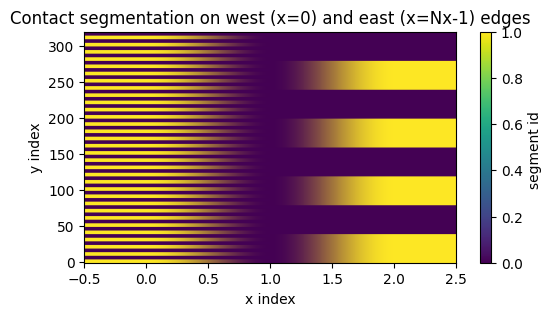

In [26]:
mask = np.zeros((Nx, Ny), dtype=int)

# mark west segments with +1..+N_in
xW = 0
for i, (y0, y1) in enumerate(west_segs, start=1):
    mask[xW, y0:y1] = i%2

# mark east segments with -(1..M_out)
xE = Nx-1
for j, (y0, y1) in enumerate(east_segs, start=1):
    mask[xE, y0:y1] = j%2

plt.figure(figsize=(6,3))
plt.imshow(mask.T, origin="lower", aspect="auto")
plt.colorbar(label="segment id ")
plt.title("Contact segmentation on west (x=0) and east (x=Nx-1) edges")
plt.xlabel("x index"); plt.ylabel("y index")
plt.show()

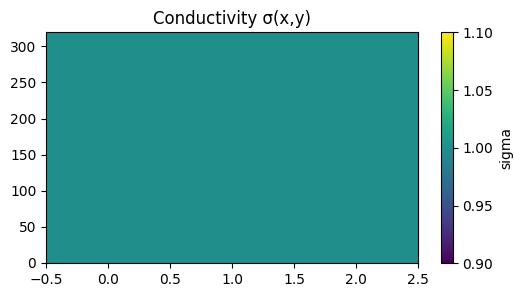

In [27]:
rng = np.random.default_rng(0)

sigma0 = 1.0
disorder_strength = 0   # 0 -> uniform

sigma = sigma0 * (1.0 + disorder_strength * rng.standard_normal((Nx, Ny)))
sigma = np.clip(sigma, 0.05*sigma0, None)  # keep positive

plt.figure(figsize=(6,3))
plt.imshow(sigma.T, origin="lower", aspect="auto")
plt.colorbar(label="sigma")
plt.title("Conductivity σ(x,y)")
plt.show()

In [28]:
def idx(ix, iy):
    return ix*Ny + iy
n_nodes = Nx*Ny

In [29]:
# Example input image: random bits on West edge
bits = rng.integers(0, 2, size=N_in)
V_in = np.where(bits == 1, V1, V0)

# East drains set to 0 (ground)
V_east = 0.0

# Create Dirichlet mask/value arrays
is_dirichlet = np.zeros((Nx, Ny), dtype=bool)
phi_dir      = np.zeros((Nx, Ny), dtype=float)

# West edge: x=0, segmented
xW = 0
for i, (y0, y1) in enumerate(west_segs):
    is_dirichlet[xW, y0:y1] = True
    phi_dir[xW, y0:y1] = V_in[i]

# East edge: x=Nx-1, segmented drains at 0 V
xE = Nx-1
for j, (y0, y1) in enumerate(east_segs):
    is_dirichlet[xE, y0:y1] = True
    phi_dir[xE, y0:y1] = V_east

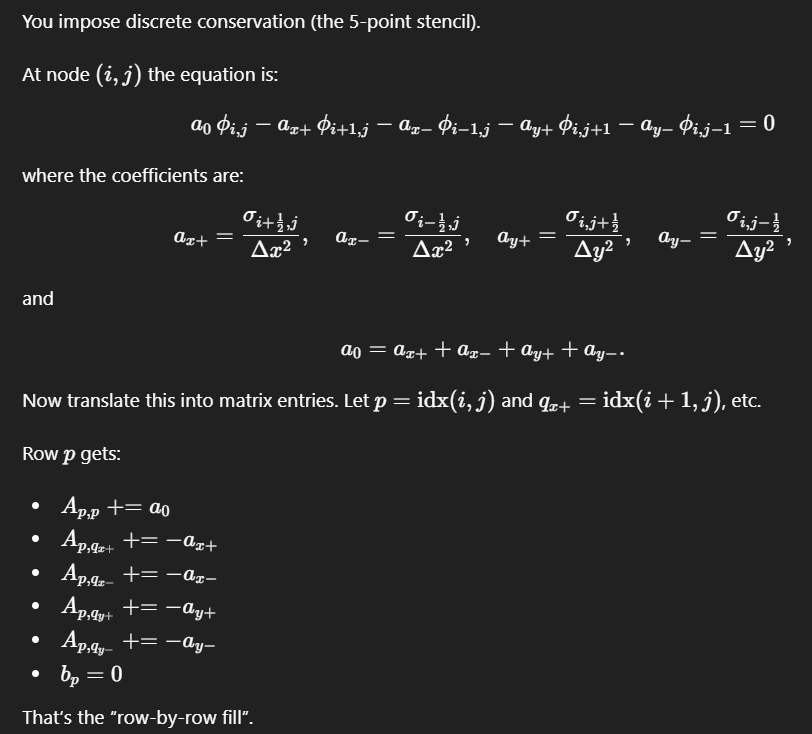

In [30]:
rows = []
cols = []
data = []
b = np.zeros(n_nodes, dtype=float)

def add_entry(r, c, v):
    rows.append(r); cols.append(c); data.append(v)

# Face conductivities: σ at half steps via arithmetic average (good enough for Tier 1)
def sig_xp(ix, iy):  # σ at (ix+1/2, iy)
    return 0.5*(sigma[ix, iy] + sigma[ix+1, iy])

def sig_xm(ix, iy):  # σ at (ix-1/2, iy)
    return 0.5*(sigma[ix, iy] + sigma[ix-1, iy])

def sig_yp(ix, iy):  # σ at (ix, iy+1/2)
    return 0.5*(sigma[ix, iy] + sigma[ix, iy+1])

def sig_ym(ix, iy):  # σ at (ix, iy-1/2)
    return 0.5*(sigma[ix, iy] + sigma[ix, iy-1])

for ix in range(Nx):
    for iy in range(Ny):
        p = idx(ix, iy)

        # Dirichlet nodes: phi = prescribed
        if is_dirichlet[ix, iy]:
            add_entry(p, p, 1.0)
            b[p] = phi_dir[ix, iy]
            continue

        # Build divergence-form stencil.
        # Neumann boundaries (insulating) on North/South and on any non-Dirichlet edges
        # are implemented by "dropping" flux terms that would go out of domain.

        diag = 0.0

        # x+ neighbor
        if ix + 1 < Nx:
            # if neighbor is Dirichlet, treat its phi as known in RHS
            s = sig_xp(ix, iy) / dx**2
            if is_dirichlet[ix+1, iy]:
                diag += s
                b[p] += s * phi_dir[ix+1, iy]
            else:
                diag += s
                add_entry(p, idx(ix+1, iy), -s)

        # x- neighbor
        if ix - 1 >= 0:
            s = sig_xm(ix, iy) / dx**2
            if is_dirichlet[ix-1, iy]:
                diag += s
                b[p] += s * phi_dir[ix-1, iy]
            else:
                diag += s
                add_entry(p, idx(ix-1, iy), -s)

        # y+ neighbor
        if iy + 1 < Ny:
            s = sig_yp(ix, iy) / dy**2
            if is_dirichlet[ix, iy+1]:
                diag += s
                b[p] += s * phi_dir[ix, iy+1]
            else:
                diag += s
                add_entry(p, idx(ix, iy+1), -s)

        # y- neighbor
        if iy - 1 >= 0:
            s = sig_ym(ix, iy) / dy**2
            if is_dirichlet[ix, iy-1]:
                diag += s
                b[p] += s * phi_dir[ix, iy-1]
            else:
                diag += s
                add_entry(p, idx(ix, iy-1), -s)

        # Diagonal
        add_entry(p, p, diag)

A = sp.csr_matrix((data, (rows, cols)), shape=(n_nodes, n_nodes))

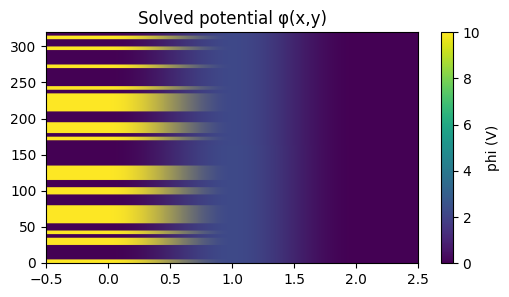

In [31]:
phi_vec = spla.spsolve(A, b)
phi = phi_vec.reshape((Nx, Ny))

plt.figure(figsize=(6,3))
plt.imshow(phi.T, origin="lower", aspect="auto")
plt.colorbar(label="phi (V)")
plt.title("Solved potential φ(x,y)")
plt.show()

Input bits: [1 0 0 0 0 1 1 0 1 0 0 1 1 1 1 1 0 0 0 1 1 0 0 1 1 1 1 0 0 0 0 0 0 0 1 0 1
 1 1 0 0 0 1 1 1 1 1 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0]
V_in: [10.  0.  0.  0.  0. 10. 10.  0. 10.  0.  0. 10. 10. 10. 10. 10.  0.  0.
  0. 10. 10.  0.  0. 10. 10. 10. 10.  0.  0.  0.  0.  0.  0.  0. 10.  0.
 10. 10. 10.  0.  0.  0. 10. 10. 10. 10. 10.  0. 10.  0.  0.  0.  0.  0.
 10.  0.  0.  0.  0. 10.  0.  0. 10.  0.]
I_out (features): [0.11025983 0.11031069 0.11015977 0.10988172 0.10968053 0.10948654
 0.10908584 0.10887804]


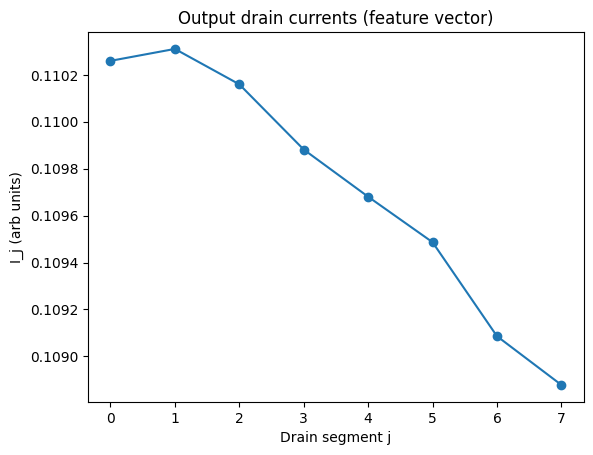

In [32]:
# East boundary index and interior index
xE = Nx - 1
xI = Nx - 2

# Face conductivity at the east interface (xI+1/2)
sigma_face = 0.5*(sigma[xI, :] + sigma[xE, :])

# Normal current density into the East lead (positive if flowing out of device into lead)
jn = -sigma_face * (phi[xE, :] - phi[xI, :]) / dx   # phi[xE,:] is 0 on drains

# Integrate by segments
I_out = np.zeros(M_out)
for j, (y0, y1) in enumerate(east_segs):
    I_out[j] = np.sum(jn[y0:y1]) * dy

print("Input bits:", bits)
print("V_in:", V_in)
print("I_out (features):", I_out)

plt.figure()
plt.plot(I_out, marker="o")
plt.title("Output drain currents (feature vector)")
plt.xlabel("Drain segment j")
plt.ylabel("I_j (arb units)")
plt.show()

In [33]:
def solve_features(V_in, sigma, west_segs, east_segs, V_east=0.0):
    Nx, Ny = sigma.shape
    dx = Lx/(Nx-1); dy = Ly/(Ny-1)

    is_dir = np.zeros((Nx, Ny), dtype=bool)
    phi_d  = np.zeros((Nx, Ny), dtype=float)

    # West
    xW = 0
    for i, (y0, y1) in enumerate(west_segs):
        is_dir[xW, y0:y1] = True
        phi_d[xW, y0:y1] = V_in[i]

    # East drains at V_east
    xE = Nx-1
    for (y0, y1) in east_segs:
        is_dir[xE, y0:y1] = True
        phi_d[xE, y0:y1] = V_east

    def idx(ix, iy): return ix*Ny + iy
    n_nodes = Nx*Ny

    rows=[]; cols=[]; data=[]
    b = np.zeros(n_nodes, dtype=float)

    def add(r,c,v):
        rows.append(r); cols.append(c); data.append(v)

    def sig_xp(ix, iy): return 0.5*(sigma[ix, iy] + sigma[ix+1, iy])
    def sig_xm(ix, iy): return 0.5*(sigma[ix, iy] + sigma[ix-1, iy])
    def sig_yp(ix, iy): return 0.5*(sigma[ix, iy] + sigma[ix, iy+1])
    def sig_ym(ix, iy): return 0.5*(sigma[ix, iy] + sigma[ix, iy-1])

    for ix in range(Nx):
        for iy in range(Ny):
            p = idx(ix, iy)
            if is_dir[ix, iy]:
                add(p, p, 1.0)
                b[p] = phi_d[ix, iy]
                continue

            diag = 0.0

            if ix+1 < Nx:
                s = sig_xp(ix, iy)/dx**2
                if is_dir[ix+1, iy]:
                    diag += s; b[p] += s*phi_d[ix+1, iy]
                else:
                    diag += s; add(p, idx(ix+1, iy), -s)

            if ix-1 >= 0:
                s = sig_xm(ix, iy)/dx**2
                if is_dir[ix-1, iy]:
                    diag += s; b[p] += s*phi_d[ix-1, iy]
                else:
                    diag += s; add(p, idx(ix-1, iy), -s)

            if iy+1 < Ny:
                s = sig_yp(ix, iy)/dy**2
                if is_dir[ix, iy+1]:
                    diag += s; b[p] += s*phi_d[ix, iy+1]
                else:
                    diag += s; add(p, idx(ix, iy+1), -s)

            if iy-1 >= 0:
                s = sig_ym(ix, iy)/dy**2
                if is_dir[ix, iy-1]:
                    diag += s; b[p] += s*phi_d[ix, iy-1]
                else:
                    diag += s; add(p, idx(ix, iy-1), -s)

            add(p, p, diag)

    A = sp.csr_matrix((data, (rows, cols)), shape=(n_nodes, n_nodes))
    phi_vec = spla.spsolve(A, b)
    phi = phi_vec.reshape((Nx, Ny))

    # Output currents
    xE = Nx-1; xI = Nx-2
    sigma_face = 0.5*(sigma[xI, :] + sigma[xE, :])
    jn = -sigma_face * (phi[xE, :] - phi[xI, :]) / dx

    I_out = np.zeros(len(east_segs))
    for j, (y0, y1) in enumerate(east_segs):
        I_out[j] = np.sum(jn[y0:y1]) * dy

    return phi, I_out


In [34]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

digits = load_digits()
imgs = digits.images          # (n, 8, 8), values 0..16
labels = digits.target        # (n,)

H, W = imgs.shape[1], imgs.shape[2]   # 8, 8
Npix = H * W

print("Digits:", imgs.shape, "labels:", labels.shape)

Digits: (1797, 8, 8) labels: (1797,)


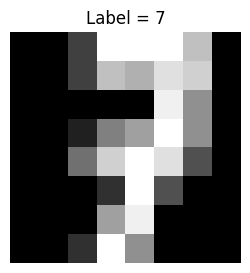

In [35]:
idx = np.random.randint(0, 1797)
plt.figure(figsize=(3,3))
plt.imshow(digits.images[idx], cmap="gray")
plt.title(f"Label = {digits.target[idx]}")
plt.axis("off")
plt.show()

In [36]:
def img_to_Vin(img, N_in, V0=0.0, V1=1.0):
    """
    Map an 8x8 image (values 0..16) to N_in voltages in [V0, V1].
    - If N_in == 64: direct flatten.
    - Else: average-pool into N_in bins (simple, stable).
    """
    x = img.astype(float).reshape(-1)          # length 64
    x = x / x.max() if x.max() > 0 else x      # normalize to [0,1]

    if N_in == x.size:
        v = V0 + (V1 - V0) * x
        return v

    # pool 64 pixels into N_in bins (N_in <= 64 is typical)
    # split indices as evenly as possible
    edges = np.linspace(0, x.size, N_in + 1, dtype=int)
    v = np.zeros(N_in, dtype=float)
    for i in range(N_in):
        seg = x[edges[i]:edges[i+1]]
        v[i] = seg.mean() if seg.size else 0.0
    v = V0 + (V1 - V0) * v
    return v

In [37]:
n_samples = 20  # start small; increase later

X = np.zeros((n_samples, M_out), dtype=float)
Y = labels[:n_samples].copy()

for n in range(n_samples):
    V_in = img_to_Vin(imgs[n], N_in, V0=V0, V1=V1)
    _, I_out = solve_features(V_in, sigma, west_segs, east_segs, V_east=0.0)
    X[n, :] = I_out

print("X shape:", X.shape, "Y shape:", Y.shape)

X shape: (20, 8) Y shape: (20,)


In [38]:
V_in

array([ 0.   ,  0.   ,  3.75 ,  8.75 ,  2.5  ,  0.   ,  0.   ,  0.   ,
        0.   ,  0.   ,  6.875, 10.   ,  6.25 ,  0.   ,  0.   ,  0.   ,
        0.   ,  0.   ,  5.   ,  8.75 , 10.   ,  1.25 ,  0.   ,  0.   ,
        0.   ,  0.   ,  0.625,  7.5  ,  7.5  ,  6.875,  0.   ,  0.   ,
        0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  6.875,  1.875,  0.   ,
        0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  3.125,  6.875,  0.   ,
        0.   ,  0.   ,  0.625,  2.5  ,  2.5  ,  4.375, 10.   ,  1.25 ,
        0.   ,  0.   ,  4.375, 10.   , 10.   ,  8.125,  6.875,  0.625])

In [39]:
X[1, :]

array([0.07646926, 0.07656495, 0.07669227, 0.07675894, 0.07671344,
       0.07669186, 0.0766787 , 0.0766751 ])

In [40]:
X[2, :]

array([0.08387701, 0.08399569, 0.08408   , 0.08416013, 0.08430198,
       0.0844408 , 0.08455107, 0.08457452])

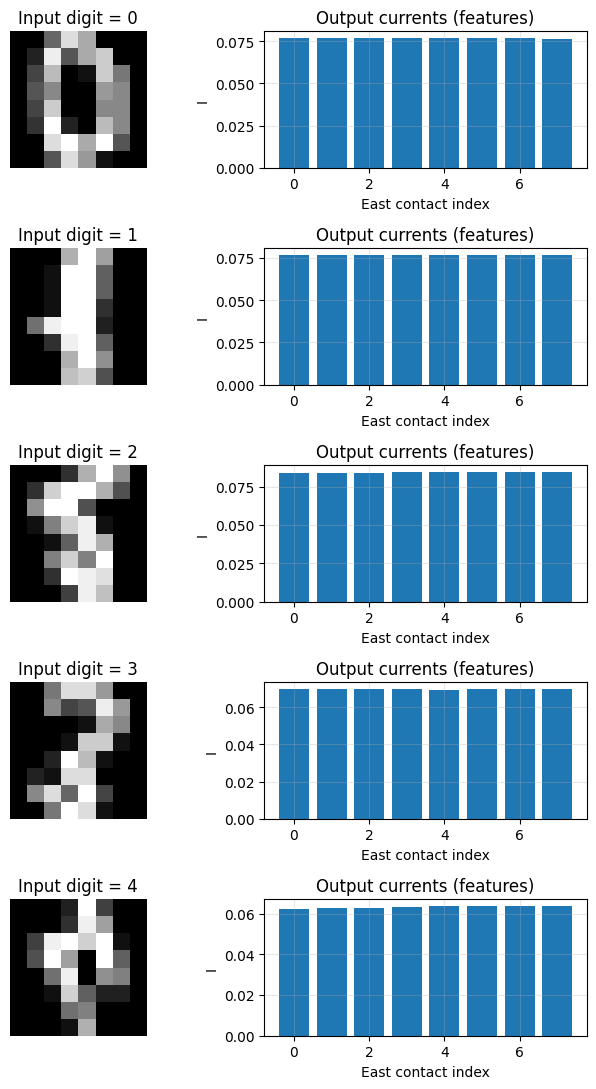

In [41]:
def show_entry_exit(k_list):
    fig, axes = plt.subplots(len(k_list), 2, figsize=(7, 2.2*len(k_list)))
    if len(k_list) == 1:
        axes = np.array([axes])

    for row, k in enumerate(k_list):
        img = imgs[k]
        V_in = img_to_Vin(img, N_in, V0=V0, V1=V1)
        _, I_out = solve_features(V_in, sigma, west_segs, east_segs, V_east=0.0)
        ax0, ax1 = axes[row, 0], axes[row, 1]
        ax0.imshow(img, cmap="gray", origin="lower")
        ax0.set_title(f"Input digit = {labels[k]}")
        ax0.axis("off")

        ax1.bar(np.arange(M_out), I_out)
        ax1.set_title("Output currents (features)")
        ax1.set_xlabel("East contact index")
        ax1.set_ylabel("I")
        ax1.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

show_entry_exit([0, 1, 2, 3, 4])

In [42]:
V_a = np.zeros(N_in); V_a[0] = 1.0            # single hot contact
V_b = np.zeros(N_in); V_b[-1] = 1.0           # different hot contact

_, I_a = solve_features(V_a, sigma, west_segs, east_segs, V_east=0.0)
_, I_b = solve_features(V_b, sigma, west_segs, east_segs, V_east=0.0)

print("||Ia-Ib|| =", np.linalg.norm(I_a - I_b))
print("Ia first 10:", I_a[:10])
print("Ib first 10:", I_b[:10])

||Ia-Ib|| = 9.897998236490426e-05
Ia first 10: [0.00042547 0.00041187 0.00040031 0.00039076 0.00038318 0.00037753
 0.00037377 0.0003719 ]
Ib first 10: [0.0003719  0.00037377 0.00037753 0.00038318 0.00039076 0.00040031
 0.00041187 0.00042547]


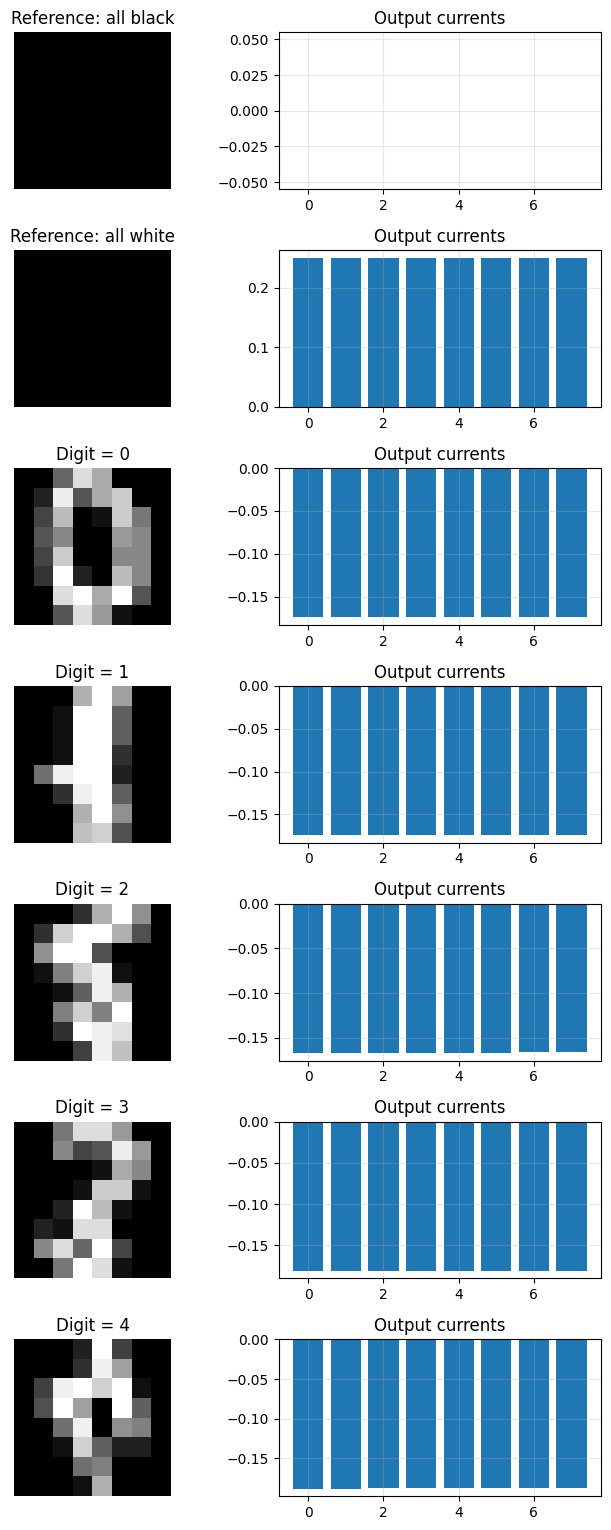

In [43]:
def show_entry_exit_with_refs(k_list):
    fig, axes = plt.subplots(len(k_list)+2, 2, figsize=(7, 2.2*(len(k_list)+2)))

    # reference 1: all black (zero)
    img0 = np.zeros_like(imgs[0])
    Vin0 = img_to_Vin(img0, N_in, V0=V0, V1=V1)
    _, I0 = solve_features(Vin0, sigma, west_segs, east_segs, V_east=0.0)

    axes[0,0].imshow(img0, cmap="gray", origin="lower")
    axes[0,0].set_title("Reference: all black")
    axes[0,0].axis("off")
    axes[0,1].bar(np.arange(M_out), I0)
    axes[0,1].set_title("Output currents")
    axes[0,1].grid(True, alpha=0.3)

    # reference 2: all white (max)
    img1 = np.ones_like(imgs[0]) * imgs[0].max()
    Vin1 = img_to_Vin(img1, N_in, V0=V0, V1=V1)
    _, I1 = solve_features(Vin1, sigma, west_segs, east_segs, V_east=0.0)

    axes[1,0].imshow(img1, cmap="gray", origin="lower")
    axes[1,0].set_title("Reference: all white")
    axes[1,0].axis("off")
    axes[1,1].bar(np.arange(M_out), I1)
    axes[1,1].set_title("Output currents")
    axes[1,1].grid(True, alpha=0.3)

    # real digits
    for row, k in enumerate(k_list, start=2):
        img = imgs[k]
        V_in = img_to_Vin(img, N_in, V0=V0, V1=V1)
        _, I_out = solve_features(V_in, sigma, west_segs, east_segs, V_east=0.0)

        axes[row,0].imshow(img, cmap="gray", origin="lower")
        axes[row,0].set_title(f"Digit = {labels[k]}")
        axes[row,0].axis("off")

        axes[row,1].bar(np.arange(M_out), I_out - I1)
        axes[row,1].set_title("Output currents")
        axes[row,1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

show_entry_exit_with_refs([0,1,2,3,4])
